In [1]:
#importando bibliotecas
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
%matplotlib inline

import requests
from io import BytesIO

In [2]:
#carrega a base de bados
df = pd.read_csv('vinhos_dataset_reduced.csv' , index_col=0)

In [3]:
# Certificando que esta usando a df sem duplicadas
df.shape

(5320, 10)

In [4]:
#mostra cabecario e primeiras 5 linhas
df.head()

,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
citric_acid,,,,,,,,,,
-2.164515,-0.699699,0.523880,1.100996,1.779304,0.177941,-0.969152,5,red,1.594818,-1.753919
-2.164515,-0.544135,1.120736,0.763753,-0.153797,0.979389,-0.631833,5,red,2.565734,-0.786828
-1.892672,-0.610806,0.957957,0.831202,0.220351,0.779027,-0.631833,5,red,2.061356,-1.345931
1.641293,-0.699699,0.496751,1.168444,-0.403229,0.311515,-0.631833,6,red,1.865803,-1.191760
-2.164515,-0.721923,0.496751,1.100996,1.779304,0.177941,-0.969152,5,red,1.426692,-1.599748


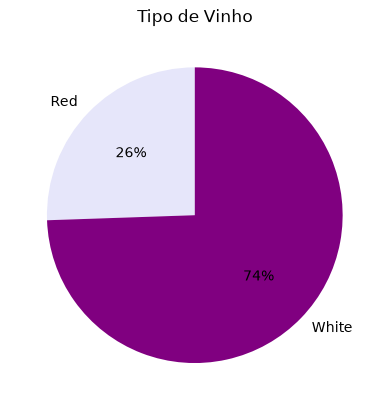

In [5]:
# PLotando em formato pizza a quantidade em % de vinhos red e white
num_red = df[df['color'] == 'red'].shape[0]
num_white = df[df['color'] == 'white'].shape[0]
plt.pie(
    [num_red, num_white],
    labels=['Red', 'White'],
    startangle=90,
    autopct='%1.f%%',
    colors=['lavender', 'purple'])
plt.title('Tipo de Vinho')
plt.show()

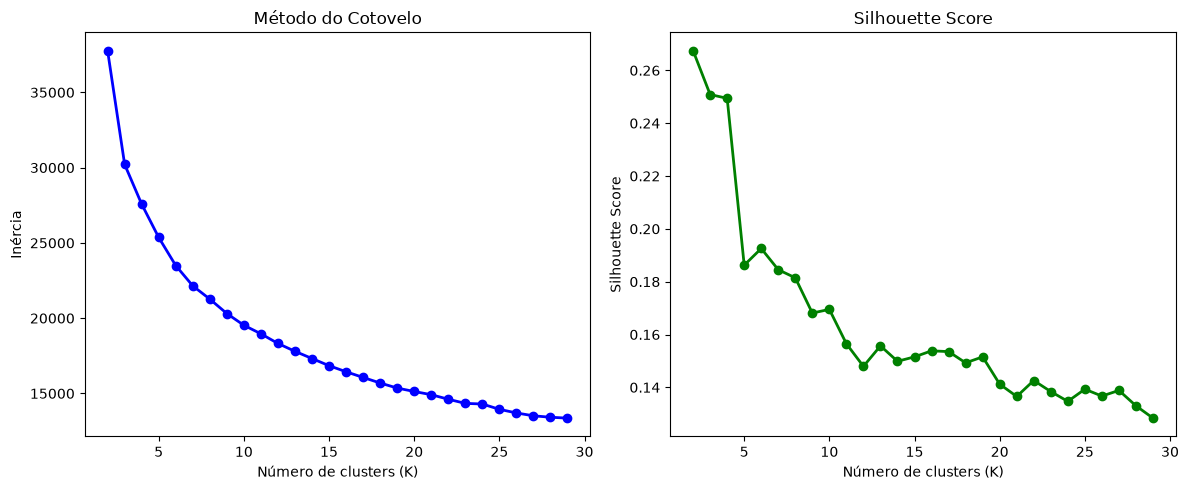

In [11]:
#importando bibliotecas faltantes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Carrega a df novamente (nao entendi porque teve que carregar novamente ?)
df = pd.read_csv(
    "vinhos_dataset_reduced.csv"
)

# Seleciona todos os "features" exceto qualidade e cor
features = [
    'citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'combined_acidity',
       'combined_sulfur_dioxide'
]

X = df[features]

# Faz o scaler dos "features" usando o standardscaler e transforma usando a formula z = X - X_mean / X_std - agora todos os valores estao em escalas parecidas e nao pH entre 1 e 14 e sultatios entre 0 e 1 por examplo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Teste do numero de clusters (nao funcionou com 1 a 30)
ks = range(2, 30)

inercias = []
silhouettes = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=1e-4,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    # Inercia
    inercias.append(km.inertia_)

    # Silhouette
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

# Plota os diagnosticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(ks, inercias, 'bo-', linewidth=2)
ax1.set_title('Método do Cotovelo')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inércia')

# Silhouette
ax2.plot(ks, silhouettes, 'go-', linewidth=2)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

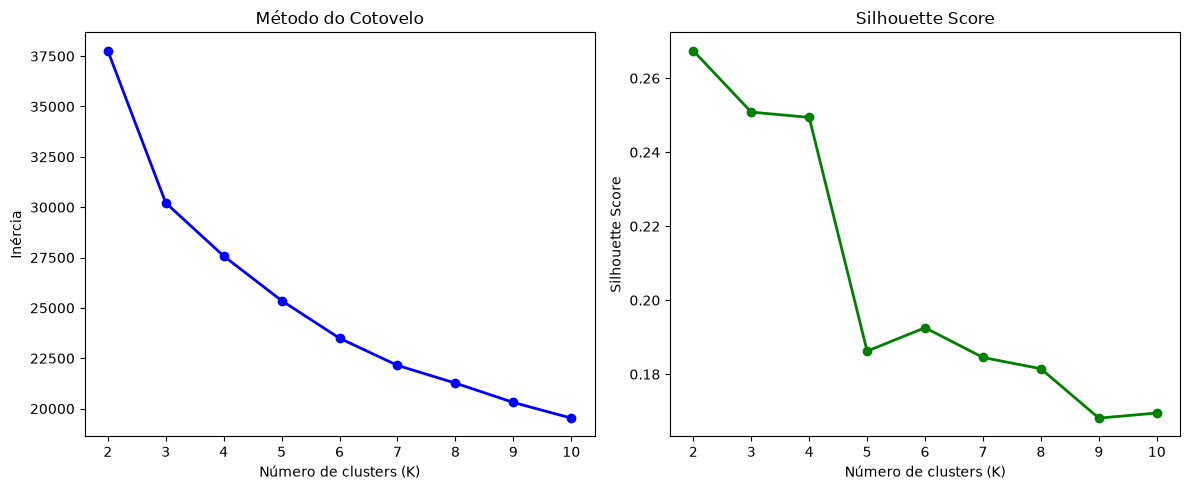

In [ ]:
# Teste do numero de clusters (agora somente 10 ks - 2 a 11 por curiosidade)
ks = range(2, 11)

inercias = []
silhouettes = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=1e-4,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    # Inercia
    inercias.append(km.inertia_)

    # Silhouette
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

# Plota os diagnosticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(ks, inercias, 'bo-', linewidth=2)
ax1.set_title('Método do Cotovelo')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inércia')

# Silhouette
ax2.plot(ks, silhouettes, 'go-', linewidth=2)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [13]:
# K-Means com 4 clusters (do grafico de Silhoetes (distancia entre pontos mesmo cluster e distancia de outros clusters) no ponto de inflexao ja que o ponto de inflexao de inercia (distancia entre pontos do mesmo cluster) nao e muito nitido)
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

# Ajusta o modelo e atribui cada vinho a um cluster
df['cluster'] = kmeans.fit_predict(X_scaled)

# contagem de vinhos red e whites de cada cluster
cluster_color = pd.crosstab(
    df['cluster'],
    df['color']
)

print(cluster_color)

# contagem de vinhos qualidades de cada cluster
cluster_quality = pd.crosstab(
    df['cluster'],
    df['quality']
)

print(cluster_quality)

color    red  white
cluster            
0         52   2403
1        500     56
2          3   1416
3        804     86
quality   3   4    5     6    7    8  9
cluster                                
0         7  77  500  1141  606  120  4
1         4  17  195   226  103   11  0
2        12  41  616   641   95   13  1
3         7  71  441   315   52    4  0


In [14]:
# Resumo de cada cluster

summary = df.groupby('cluster')[features + ['quality']].agg(
    ['mean', 'std', 'min', 'max']
)

summary

citric_acid                               residual_sugar            \
               mean       std       min       max           mean       std   
cluster                                                                      
0          0.028448  0.684875 -2.164515  6.194671      -0.415262  0.539463   
1          1.079638  0.918991 -0.941220  9.116989      -0.496811  0.415863   
2          0.260955  0.917020 -2.164515  4.631571       1.274904  0.949091   
3         -1.169003  0.782861 -2.164515  1.097606      -0.576846  0.279427   

                             chlorides            ... combined_acidity  \
              min        max      mean       std  ...              min   
cluster                                           ...                    
0       -0.988604   2.322686 -0.443786  0.347279  ...        -2.347641   
1       -0.944157   2.322686  1.356706  2.042767  ...        -1.299010   
2       -0.910822  13.501067 -0.131383  0.623191  ...        -2.158499   
3       -0.944157   1.322632  0.586065  0.600233  ...        -1.624723   

                  combined_sulfur_dioxide                                 \
              max                    mean       std       min        max   
cluster                                                                    
0        1.821738                0.025552  0.861631 -2.358145   3.785637   
1        5.925913               -1.318610  0.923827 -2.420424   3.014554   
2        2.923002                1.274782  1.057682 -1.865315  14.344658   
3        5.400767               -1.279211  0.779713 -2.407968   1.631013   

          quality                    
             mean       std min max  
cluster                              
0        6.074542  0.898101   3   9  
1        5.791367  0.871778   3   8  
2        5.570120  0.742510   3   9  
3        5.388764  0.767366   3   8  

[4 rows x 40 columns]

Variância explicada - PC1: 27.66%, PC2: 24.95% (Total: 52.61%)


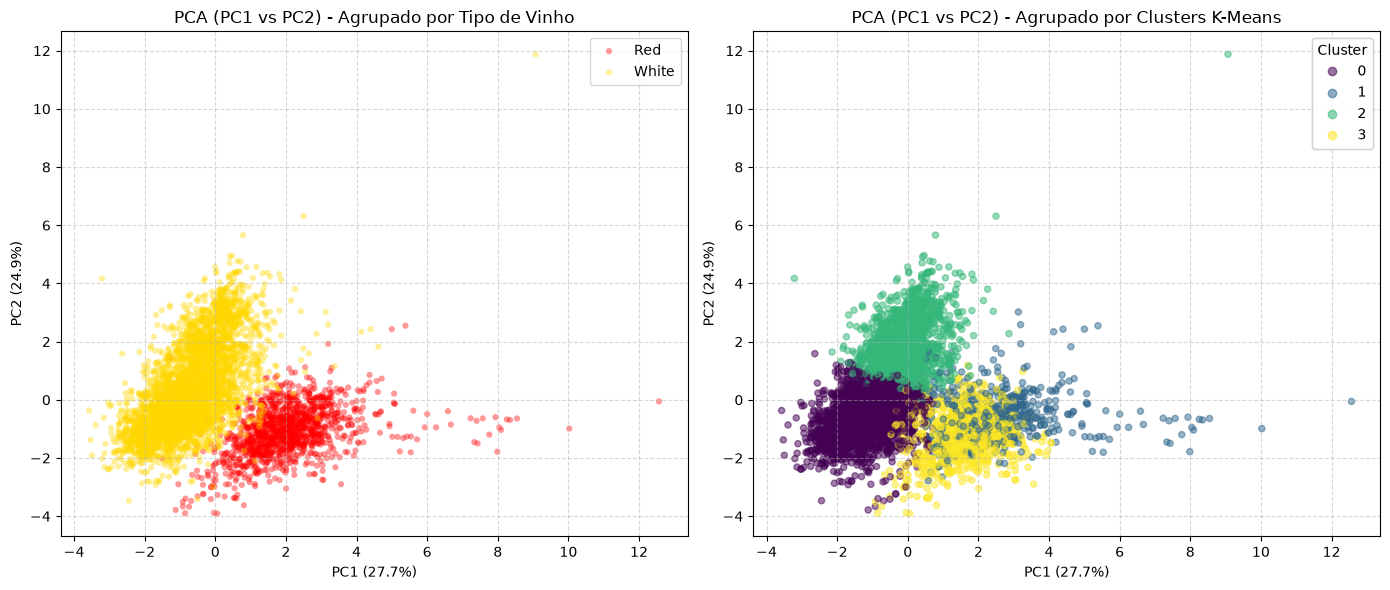

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Seleção das colunas numéricas (excluindo rótulos/targets)
features = [
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'combined_acidity',
    'combined_sulfur_dioxide',
]

X = df[features]

# Normalização dos dados (requisito do PCA para evitar viés de escala - por excesso de zelo ja que os dados ja foram normalizados)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicação do PCA para 2 componentes principais
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Criando um DataFrame com PC1 e PC2 juntamente com a cor e os clusters
df_pca = pd.DataFrame(
    data=principal_components, columns=['PC1', 'PC2'], index=df.index
)
df_pca['color'] = df['color']
if 'cluster' in df.columns:
  df_pca['cluster'] = df['cluster']

# Métrica de quanta informação foi mantida
exp_var = pca.explained_variance_ratio_
print(
    f'Variância explicada - PC1: {exp_var[0]*100:.2f}%, PC2:'
    f' {exp_var[1]*100:.2f}% (Total: {sum(exp_var)*100:.2f}%)'
)

# Plotagem do Gráfico 2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Mapeamento por Tipo de Vinho (Color)
colors_map = {'red': 'red', 'white': 'gold'}
for wine_type, group in df_pca.groupby('color'):
  ax1.scatter(
      group['PC1'],
      group['PC2'],
      c=colors_map[wine_type],
      label=wine_type.capitalize(),
      alpha=0.4,
      edgecolors='none',
      s=20,
  )

ax1.set_title('PCA (PC1 vs PC2) - Agrupado por Tipo de Vinho')
ax1.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Gráfico 2: Mapeamento por Clusters do K-Means (se calculados)
if 'cluster' in df_pca.columns:
  scatter = ax2.scatter(
      df_pca['PC1'],
      df_pca['PC2'],
      c=df_pca['cluster'],
      cmap='viridis',
      alpha=0.5,
      s=20,
  )
  legend2 = ax2.legend(
      *scatter.legend_elements(), title='Cluster', loc='upper right'
  )
  ax2.add_artist(legend2)
  ax2.set_title('PCA (PC1 vs PC2) - Agrupado por Clusters K-Means')
  ax2.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
  ax2.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
  ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [16]:
# Obtém os pesos (loadings) das variáveis em PCA1 e PCA2

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=features
)

print(loadings)

                             PCA1      PCA2
citric_acid              0.006371  0.231980
residual_sugar          -0.001333  0.554678
chlorides                0.462940 -0.049538
density                  0.488130  0.354132
pH                       0.071048 -0.286002
sulphates                0.386459 -0.168550
alcohol                 -0.298341 -0.408221
combined_acidity         0.487218 -0.138443
combined_sulfur_dioxide -0.258042  0.463288


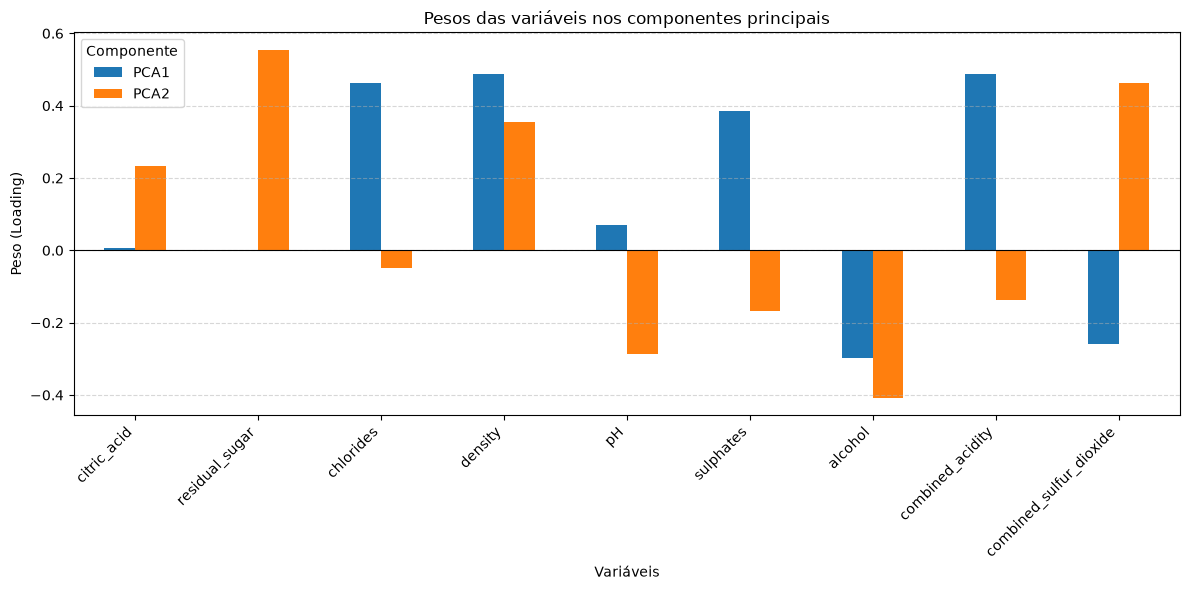

In [17]:
# Gráfico dos pesos das variáveis em PCA1 e PCA2

loadings.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Pesos das variáveis nos componentes principais')
plt.xlabel('Variáveis')
plt.ylabel('Peso (Loading)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Componente')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()